In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

### Parameter Values

- $\alpha$: infection rate from living hosts
- $\beta$: death rate from disease
- $\gamma$: infection rate from deceased hosts
- $\delta$: death rate of fungus in dead hosts
- $\zeta$: recovery rate (should have something to do with temperature)
- $\pi$: natural birth/death rate

If we want to add an equation for symptomatic (split $I$ into $I_1$ and $I_2$), we would have

- $\frac{dI_1}{dt} = \alpha_1 SI_1 + \alpha_2 SI_2 + \gamma R_1 - \beta_1 I_1$
- $\frac{dI_2}{dt} = \beta_1 I_1 - \beta_2 I_2$

where $\alpha_1 > \alpha_2$. Then $\frac{dR_1}{dt}$ would change $\beta I$ to $\beta_2 I_2$.

In [54]:
# SIRR model  (FIX PARAMETERS WHEN WE GET THEM)
def disease_model(t, y, params=[.1e1, .01e1, .1e1, .01e1, .8e1, .5e1]):
    S, I, R1, R2 = y    # unpack variables
    alpha, beta, gamma, delta, zeta, pi = params
    
    # define system of differential equations
    dS = -alpha*S*I - gamma*S*R1 + zeta*I + pi*S
    dI = alpha*S*I + gamma*S*R1 - beta*I - zeta*I
    dR1 = beta*I - delta*R1
    dR2 = delta*R1

    return [dS, dI, dR1, dR2]

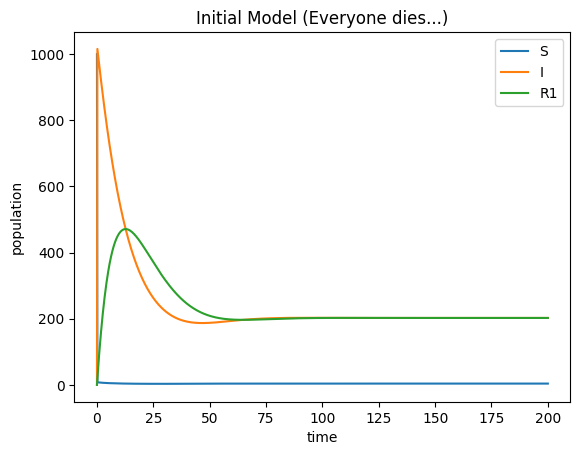

In [56]:
sol = solve_ivp(disease_model, t_span=[0, 200], y0=[1000, 1, 0, 0], t_eval=np.linspace(0, 200, 1000))
t_vals = np.linspace(0, 200, 1000)

plt.plot(t_vals, sol.y[0], label='S')
plt.plot(t_vals, sol.y[1], label="I")
plt.plot(t_vals, sol.y[2], label="R1")
# plt.plot(t_vals, sol.y[3], label="R2")
plt.title("Initial Model (Everyone dies...)")
plt.xlabel("time")
plt.ylabel("population")
# plt.ylim(0, 100)
plt.legend()

#### Try it with periodic infection rate to reflect weather patterns

--> modify original model to have periodic motion

In [ ]:
# SIRR model  (FIX PARAMETERS WHEN WE GET THEM)
def disease_model_periodic(t, y, params=[.1e1, .01e1, .1e1, .01e1, .8e1, .5e1]):
    S, I, R1, R2 = y    # unpack variables
    alpha, beta, gamma, delta, zeta, pi = params
    
    # define system of differential equations
    dS = -alpha*S*I - gamma*S*R1 + zeta*I + pi*S
    dI = alpha*S*I + gamma*S*R1 - beta*I - zeta*I
    dR1 = beta*I - delta*R1
    dR2 = delta*R1

    return [dS, dI, dR1, dR2]